In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **IMPORT LIBRARY**

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

## **DATA**

#### TRAIN DATA

In [ ]:
path = '/content/drive/My Drive/BDC-SatriaData-2024/dataset_penyisihan_bdc_2024.csv'
data = pd.read_csv(path, delimiter=';')
data.head()

,text,label
0,Kunjungan Prabowo ini untuk meresmikan dan men...,Sumber Daya Alam
1,RT Anies dapat tepuk tangan meriah saat jadi R...,Politik
2,@CIqXqwGAT04tMtx4OCATxjoVq7vv/Y8HeYaIOgMFg8Y= ...,Demografi
3,RT @L3R8XFBw3WGbxRPSj0/0hHZTbqVGX7qtfwRg9zmhK7...,Politik
4,Anies Baswedan Harap ASN termasuk TNI dan Polr...,Politik


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5000 non-null   object
 1   label   5000 non-null   object
dtypes: object(2)
memory usage: 78.2+ KB


In [ ]:
data['label'].value_counts()

label
Politik                    2972
Sosial Budaya               587
Ideologi                    400
Pertahanan dan Keamanan     400
Ekonomi                     367
Sumber Daya Alam            192
Demografi                    62
Geografi                     20
Name: count, dtype: int64

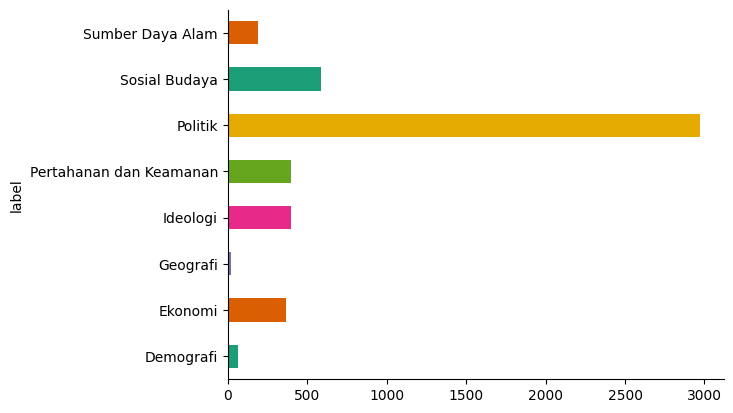

In [ ]:
data.groupby('label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

#### TEST DATA

In [ ]:
path_test = '/content/drive/My Drive/BDC-SatriaData-2024/dataset_unlabeled_penyisihan_bdc_2024.csv'
data_test = pd.read_csv(path_test, delimiter=';')
data_test.head()

,IDText,Text
0,TXT0001,Lu mau org2 pro-demokrasi di negara ini bisa p...
1,TXT0002,Prabowo ditanya soal hutang luar negeri dia me...
2,TXT0003,kiki_daliyo Ganjar Pranowo itulah beliau soso...
3,TXT0004,@kumparan Prabowo Gibran yang bisa melakukan i...
4,TXT0005,@sniperruben45 @uda_zulhendra @ainunnajib Lah ...


In [ ]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   IDText  1000 non-null   object
 1   Text    1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


## **EDA**

In [ ]:
data['label'].value_counts()

label
Politik                    2972
Sosial Budaya               587
Ideologi                    400
Pertahanan dan Keamanan     400
Ekonomi                     367
Sumber Daya Alam            192
Demografi                    62
Geografi                     20
Name: count, dtype: int64

In [ ]:
data['text'].iloc[0]

'Kunjungan Prabowo ini untuk meresmikan dan menyerahkan proyek bantuan air bersih di lima titik. #IndonesiaSentris #IndonesiaHijau #02Melanjutkan #AnakMudaIndonesiaEmas Prabowo Subianto'

In [ ]:
data['label'].iloc[0]

'Sumber Daya Alam'

In [ ]:
data['text'].iloc[100]

'Para pendukung terlihat mengerumuni Anies.Ã‚ Rupanya, pendukung ingin memberikan hadiah berupa cenderamata kepada mantan Gubernur DKI Jakarta itu.'

In [ ]:
data['label'].iloc[100]

'Politik'

## **PRAPROSES DATA**

In [ ]:
!pip install Sastrawi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 1.6 MB/s eta 0:00:00


In [ ]:
!pip install nltk tensorflow

In [ ]:
import re
import string
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.tokenize import word_tokenize

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
path = '/content/drive/My Drive/BDC-SatriaData-2024/dataset_penyisihan_bdc_2024.csv'
data = pd.read_csv(path, delimiter=';')
data.head()

,text,label
0,Kunjungan Prabowo ini untuk meresmikan dan men...,Sumber Daya Alam
1,RT Anies dapat tepuk tangan meriah saat jadi R...,Politik
2,@CIqXqwGAT04tMtx4OCATxjoVq7vv/Y8HeYaIOgMFg8Y= ...,Demografi
3,RT @L3R8XFBw3WGbxRPSj0/0hHZTbqVGX7qtfwRg9zmhK7...,Politik
4,Anies Baswedan Harap ASN termasuk TNI dan Polr...,Politik


#### Case Folding

In [ ]:
data['casefolding'] = data['text'].str.lower()
data.head()

,text,label,casefolding
0,Kunjungan Prabowo ini untuk meresmikan dan men...,Sumber Daya Alam,kunjungan prabowo ini untuk meresmikan dan men...
1,RT Anies dapat tepuk tangan meriah saat jadi R...,Politik,rt anies dapat tepuk tangan meriah saat jadi r...
2,@CIqXqwGAT04tMtx4OCATxjoVq7vv/Y8HeYaIOgMFg8Y= ...,Demografi,@ciqxqwgat04tmtx4ocatxjovq7vv/y8heyaiogmfg8y= ...
3,RT @L3R8XFBw3WGbxRPSj0/0hHZTbqVGX7qtfwRg9zmhK7...,Politik,rt @l3r8xfbw3wgbxrpsj0/0hhztbqvgx7qtfwrg9zmhk7...
4,Anies Baswedan Harap ASN termasuk TNI dan Polr...,Politik,anies baswedan harap asn termasuk tni dan polr...


#### Cleaning

In [ ]:
def remove_tweet_special(text):
    text = re.sub(r'\[re\s[^\]]+\]', '', text)
    text = re.sub('@[^\s]+', '', text)
    text = text.replace('\\t', "").replace('\\n', "").replace('\\u', "").replace('\\', "")
    text = text.encode('ascii', 'replace').decode('ascii')
    text = ' '.join(re.sub(r'([#@]\S*)|(\w+:\/\/\S+)', " ", text).split())
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("","", string.punctuation))
    text = text.strip()
    text = re.sub('\s+', ' ', text)
    text = re.sub(r"\b[a-zA-Z]\b", "", text)
    text = re.sub(r'\brt\b', '', text).strip()
    return text.replace("http://", " ").replace("https://", " ")

In [ ]:
data['cleaning'] = data['casefolding'].apply(remove_tweet_special)
data.head()

,text,label,casefolding,cleaning
0,Kunjungan Prabowo ini untuk meresmikan dan men...,Sumber Daya Alam,kunjungan prabowo ini untuk meresmikan dan men...,kunjungan prabowo ini untuk meresmikan dan men...
1,RT Anies dapat tepuk tangan meriah saat jadi R...,Politik,rt anies dapat tepuk tangan meriah saat jadi r...,anies dapat tepuk tangan meriah saat jadi rekt...
2,@CIqXqwGAT04tMtx4OCATxjoVq7vv/Y8HeYaIOgMFg8Y= ...,Demografi,@ciqxqwgat04tmtx4ocatxjovq7vv/y8heyaiogmfg8y= ...,emng bener sih pendukung ada yg goblok begitu ...
3,RT @L3R8XFBw3WGbxRPSj0/0hHZTbqVGX7qtfwRg9zmhK7...,Politik,rt @l3r8xfbw3wgbxrpsj0/0hhztbqvgx7qtfwrg9zmhk7...,sewaktu anies bersikap kritis ke kinerja pak p...
4,Anies Baswedan Harap ASN termasuk TNI dan Polr...,Politik,anies baswedan harap asn termasuk tni dan polr...,anies baswedan harap asn termasuk tni dan polr...


In [ ]:
data['text'].iloc[1]

'RT Anies dapat tepuk tangan meriah saat jadi Rektor mewajibkan mata kuliah anti-korupsi untuk memutus mata rantai korupsi.. #AminMiskinkanKoruptor https://t.co/hgXsoQGaEa [RE ekowboy2]'

In [ ]:
data['cleaning'].iloc[1]

'anies dapat tepuk tangan meriah saat jadi rektor mewajibkan mata kuliah antikorupsi untuk memutus mata rantai korupsi'

#### Tokenizing

In [ ]:
def word_tokenize_wrapper(cleaning):
  return word_tokenize(cleaning)

In [ ]:
data['tokenize'] = data['cleaning'].apply(word_tokenize_wrapper)
data.head()

,text,label,casefolding,cleaning,tokenize
0,Kunjungan Prabowo ini untuk meresmikan dan men...,Sumber Daya Alam,kunjungan prabowo ini untuk meresmikan dan men...,kunjungan prabowo ini untuk meresmikan dan men...,"[kunjungan, prabowo, ini, untuk, meresmikan, d..."
1,RT Anies dapat tepuk tangan meriah saat jadi R...,Politik,rt anies dapat tepuk tangan meriah saat jadi r...,anies dapat tepuk tangan meriah saat jadi rekt...,"[anies, dapat, tepuk, tangan, meriah, saat, ja..."
2,@CIqXqwGAT04tMtx4OCATxjoVq7vv/Y8HeYaIOgMFg8Y= ...,Demografi,@ciqxqwgat04tmtx4ocatxjovq7vv/y8heyaiogmfg8y= ...,emng bener sih pendukung ada yg goblok begitu ...,"[emng, bener, sih, pendukung, ada, yg, goblok,..."
3,RT @L3R8XFBw3WGbxRPSj0/0hHZTbqVGX7qtfwRg9zmhK7...,Politik,rt @l3r8xfbw3wgbxrpsj0/0hhztbqvgx7qtfwrg9zmhk7...,sewaktu anies bersikap kritis ke kinerja pak p...,"[sewaktu, anies, bersikap, kritis, ke, kinerja..."
4,Anies Baswedan Harap ASN termasuk TNI dan Polr...,Politik,anies baswedan harap asn termasuk tni dan polr...,anies baswedan harap asn termasuk tni dan polr...,"[anies, baswedan, harap, asn, termasuk, tni, d..."


In [ ]:
data['tokenize'].iloc[1]

['anies',
 'dapat',
 'tepuk',
 'tangan',
 'meriah',
 'saat',
 'jadi',
 'rektor',
 'mewajibkan',
 'mata',
 'kuliah',
 'antikorupsi',
 'untuk',
 'memutus',
 'mata',
 'rantai',
 'korupsi']

#### Token Count for Normalization

In [ ]:
from collections import Counter

In [ ]:
all_tokens = [token for sublist in data['tokenize'] for token in sublist]

# Count frequency of each token
token_counts = Counter(all_tokens)

# Get a DataFrame of token counts
token_counts_df = pd.DataFrame(token_counts.items(), columns=['token', 'count']).sort_values(by='count', ascending=False)
token_counts_df.head()

,token,count
5,dan,2963
207,yang,2679
15,anies,2337
11,di,2237
104,ganjar,1970


In [ ]:
output_path = '/content/drive/My Drive/BDC-SatriaData-2024/token_counts.csv'
token_counts_df.to_csv(output_path, index=False)

#### Normalisasi

In [ ]:
path_to_excel = '/content/drive/My Drive/BDC-SatriaData-2024/Kamus.xlsx'
xls = pd.ExcelFile(path_to_excel)
slangWord = pd.read_excel(xls, 'Kamus')
drop_df = pd.read_excel(xls, 'Drop')

In [ ]:
slangWord_dict = {}

for index, row in slangWord.iterrows():
    if row[0] not in slangWord_dict:
        slangWord_dict[row[0]] = row[1]

def slangWordText(text):
    text = [slangWord_dict[term] if term in slangWord_dict else term for term in text]
    return text

In [ ]:
data['normalized'] = data['tokenize'].apply(slangWordText)
data['normalized'].head()

0    [kunjungan, prabowo, ini, untuk, meresmikan, d...
1    [anies, dapat, tepuk, tangan, meriah, saat, ja...
2    [memang, benar, sih, pendukung, ada, yang, bod...
3    [sewaktu, anies, bersikap, kritis, ke, kinerja...
4    [anies, baswedan, harap, asn, termasuk, tni, d...
Name: normalized, dtype: object

In [ ]:
data['normalized'].iloc[1]

['anies',
 'dapat',
 'tepuk',
 'tangan',
 'meriah',
 'saat',
 'jadi',
 'rektor',
 'mewajibkan',
 'mata',
 'kuliah',
 'anti korupsi',
 'untuk',
 'memutus',
 'mata',
 'rantai',
 'korupsi']

In [ ]:
# Membuat kamus untuk token yang akan di-drop
drop_tokens = set(drop_df['drop'])

# Menghapus token yang ada di kamus drop_df
def remove_drop_tokens(tokens):
    return [token for token in tokens if token not in drop_tokens]

In [ ]:
# Menghapus token yang ada di kamus drop_df
data['cleaned'] = data['normalized'].apply(remove_drop_tokens)

In [ ]:
data['cleaned'].head()

0    [kunjungan, prabowo, ini, untuk, meresmikan, d...
1    [anies, dapat, tepuk, tangan, meriah, saat, ja...
2    [memang, benar, sih, pendukung, ada, yang, bod...
3    [sewaktu, anies, bersikap, kritis, ke, kinerja...
4    [anies, baswedan, harap, asn, termasuk, tni, d...
Name: cleaned, dtype: object

In [ ]:
data['cleaned'].iloc[1]

['anies',
 'dapat',
 'tepuk',
 'tangan',
 'meriah',
 'saat',
 'jadi',
 'rektor',
 'mewajibkan',
 'mata',
 'kuliah',
 'anti korupsi',
 'untuk',
 'memutus',
 'mata',
 'rantai',
 'korupsi']

#### Stopword Removal

In [ ]:
from nltk.corpus import stopwords

In [ ]:
list_stopwords = stopwords.words('indonesian')
list_dialects = set(list_stopwords)

def stopwords_removal(words):
  return [word for word in words if word not in list_stopwords]

data['stopwords'] = data['cleaned'].apply(stopwords_removal)

In [ ]:
data['stopwords'].iloc[1]

['anies',
 'tepuk',
 'tangan',
 'meriah',
 'rektor',
 'mewajibkan',
 'mata',
 'kuliah',
 'anti korupsi',
 'memutus',
 'mata',
 'rantai',
 'korupsi']

#### Stemming

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemmed_wrapper(term):
  return stemmer.stem(term)

In [ ]:
data['stemming'] = data['stopwords'].apply(lambda x: [stemmer.stem(y) for y in x if isinstance(y, str)])

In [ ]:
data['stemming'].iloc[17]

['ramai',
 'twitter',
 'anies',
 'gelembung',
 'roket',
 'fenomena',
 'gemar',
 'kpop',
 'gabung',
 'amin',
 'isme']

In [ ]:
cleaned_data_path = '/content/drive/My Drive/BDC-SatriaData-2024/cleaned_data.csv'
data.to_csv(cleaned_data_path, index=False)

#### Data Hasil Stemming

In [ ]:
path = '/content/drive/My Drive/BDC-SatriaData-2024/cleaned_data.csv'
data = pd.read_csv(path)
data.head()

,text,label,casefolding,cleaning,tokenize,normalized,cleaned,stopwords,stemming
0,Kunjungan Prabowo ini untuk meresmikan dan men...,Sumber Daya Alam,kunjungan prabowo ini untuk meresmikan dan men...,kunjungan prabowo ini untuk meresmikan dan men...,"['kunjungan', 'prabowo', 'ini', 'untuk', 'mere...","['kunjungan', 'prabowo', 'ini', 'untuk', 'mere...","['kunjungan', 'prabowo', 'ini', 'untuk', 'mere...","['kunjungan', 'prabowo', 'meresmikan', 'menyer...","['kunjung', 'prabowo', 'resmi', 'serah', 'proy..."
1,RT Anies dapat tepuk tangan meriah saat jadi R...,Politik,rt anies dapat tepuk tangan meriah saat jadi r...,anies dapat tepuk tangan meriah saat jadi rekt...,"['anies', 'dapat', 'tepuk', 'tangan', 'meriah'...","['anies', 'dapat', 'tepuk', 'tangan', 'meriah'...","['anies', 'dapat', 'tepuk', 'tangan', 'meriah'...","['anies', 'tepuk', 'tangan', 'meriah', 'rektor...","['anies', 'tepuk', 'tangan', 'riah', 'rektor',..."
2,@CIqXqwGAT04tMtx4OCATxjoVq7vv/Y8HeYaIOgMFg8Y= ...,Demografi,@ciqxqwgat04tmtx4ocatxjovq7vv/y8heyaiogmfg8y= ...,emng bener sih pendukung ada yg goblok begitu ...,"['emng', 'bener', 'sih', 'pendukung', 'ada', '...","['memang', 'benar', 'sih', 'pendukung', 'ada',...","['memang', 'benar', 'sih', 'pendukung', 'ada',...","['sih', 'pendukung', 'bodoh', 'pendukung', 'ri...","['sih', 'dukung', 'bodoh', 'dukung', 'ridwan',..."
3,RT @L3R8XFBw3WGbxRPSj0/0hHZTbqVGX7qtfwRg9zmhK7...,Politik,rt @l3r8xfbw3wgbxrpsj0/0hhztbqvgx7qtfwrg9zmhk7...,sewaktu anies bersikap kritis ke kinerja pak p...,"['sewaktu', 'anies', 'bersikap', 'kritis', 'ke...","['sewaktu', 'anies', 'bersikap', 'kritis', 'ke...","['sewaktu', 'anies', 'bersikap', 'kritis', 'ke...","['anies', 'bersikap', 'kritis', 'kinerja', 'pr...","['anies', 'sikap', 'kritis', 'kerja', 'prabowo..."
4,Anies Baswedan Harap ASN termasuk TNI dan Polr...,Politik,anies baswedan harap asn termasuk tni dan polr...,anies baswedan harap asn termasuk tni dan polr...,"['anies', 'baswedan', 'harap', 'asn', 'termasu...","['anies', 'baswedan', 'harap', 'asn', 'termasu...","['anies', 'baswedan', 'harap', 'asn', 'termasu...","['anies', 'baswedan', 'harap', 'asn', 'tni', '...","['anies', 'baswedan', 'harap', 'asn', 'tni', '..."


In [ ]:
def join_tokens(tokens):
    return ' '.join(tokens)
data['text_clean'] = data['stemming'].apply(eval).apply(join_tokens)
data[['text', 'stemming', 'text_clean']].head()

,text,stemming,text_clean
0,Kunjungan Prabowo ini untuk meresmikan dan men...,"['kunjung', 'prabowo', 'resmi', 'serah', 'proy...",kunjung prabowo resmi serah proyek bantu air b...
1,RT Anies dapat tepuk tangan meriah saat jadi R...,"['anies', 'tepuk', 'tangan', 'riah', 'rektor',...",anies tepuk tangan riah rektor wajib mata kuli...
2,@CIqXqwGAT04tMtx4OCATxjoVq7vv/Y8HeYaIOgMFg8Y= ...,"['sih', 'dukung', 'bodoh', 'dukung', 'ridwan',...",sih dukung bodoh dukung ridwan kamil skema bal...
3,RT @L3R8XFBw3WGbxRPSj0/0hHZTbqVGX7qtfwRg9zmhK7...,"['anies', 'sikap', 'kritis', 'kerja', 'prabowo...",anies sikap kritis kerja prabowo anggap sopan ...
4,Anies Baswedan Harap ASN termasuk TNI dan Polr...,"['anies', 'baswedan', 'harap', 'asn', 'tni', '...",anies baswedan harap asn tni polri pegang sump...


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         5000 non-null   object
 1   label        5000 non-null   object
 2   casefolding  5000 non-null   object
 3   cleaning     4991 non-null   object
 4   tokenize     5000 non-null   object
 5   normalized   5000 non-null   object
 6   cleaned      5000 non-null   object
 7   stopwords    5000 non-null   object
 8   stemming     5000 non-null   object
 9   text_clean   5000 non-null   object
dtypes: object(10)
memory usage: 390.8+ KB


In [ ]:
data['text_clean'].head()

0    kunjung prabowo resmi serah proyek bantu air b...
1    anies tepuk tangan riah rektor wajib mata kuli...
2    sih dukung bodoh dukung ridwan kamil skema bal...
3    anies sikap kritis kerja prabowo anggap sopan ...
4    anies baswedan harap asn tni polri pegang sump...
Name: text_clean, dtype: object